In [23]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [4]:
uploaded = files.upload()
uploaded_names = list(uploaded.keys())

def find_uploaded_image(keyword, fallback_index):
  matches = [
      name for name in uploaded_names if keyword.lower() in name.lower()
  ]

  if matches:
    return '/content/' + matches[0]

  if fallback_index < len(uploaded_names):
    return '/content/' + uploaded_names[fallback_index]
  raise FileNotFoundError(f'Image Not Found: {keyword}')

shape_path = find_uploaded_image('shape', 0)
rectangle_path = find_uploaded_image('rectangle', 1)

print('Input Images Loaded:')
print(shape_path)
print(rectangle_path)

Saving rectangle.png to rectangle.png
Saving shapes.png to shapes.png
Input Images Loaded:
/content/shapes.png
/content/rectangle.png


In [5]:
image = cv2.imread(shape_path, cv2.IMREAD_GRAYSCALE)
if image is None:
  raise FileNotFoundError('Shape Image Not Found')

threshold_value, threshold_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(threshold_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

print('Threshold Value:', threshold_value)
print('Number Of Contours:', len(contours))

Threshold Value: 127.0
Number Of Contours: 6


In [6]:
for contour_id, contour in enumerate(contours):
  print(f'Contour {contour_id}: Shape={contour.shape}')

Contour 0: Shape=(24, 1, 2)
Contour 1: Shape=(134, 1, 2)
Contour 2: Shape=(146, 1, 2)
Contour 3: Shape=(17, 1, 2)
Contour 4: Shape=(117, 1, 2)
Contour 5: Shape=(4, 1, 2)


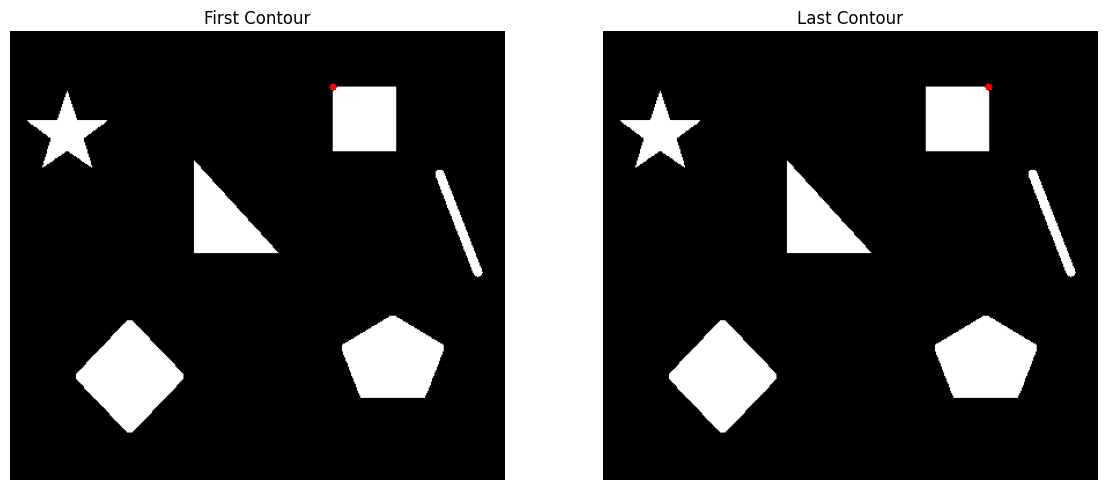

In [7]:
first_contour_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

cv2.polylines(first_contour_image, [contour[0]], isClosed=True, color=(255, 0, 0), thickness=5)

last_contour_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

cv2.polylines(last_contour_image, [contour[-1]], isClosed=True, color=(255, 0, 0), thickness=5)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(first_contour_image, cmap='gray')
plt.title('First Contour')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(last_contour_image, cmap='gray')
plt.title('Last Contour')
plt.axis('off')

plt.tight_layout()
plt.show()

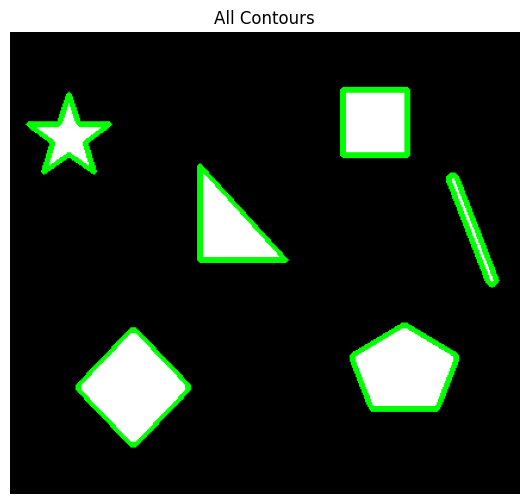

In [8]:
all_contours_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

all_contours_image = cv2.drawContours(all_contours_image, contours, -1, (0, 255, 0), 3)

plt.figure(figsize=(8, 6))

plt.imshow(all_contours_image)
plt.title('All Contours')
plt.axis('off')

plt.show()

CHAIN_APPROX_NONE:
contours_none[0].shape: (482, 1, 2); Number Of Points: 482
CHAIN_APPROX_SIMPLE:
contours_sample[0].shape: (7, 1, 2); Number Of Points: 7


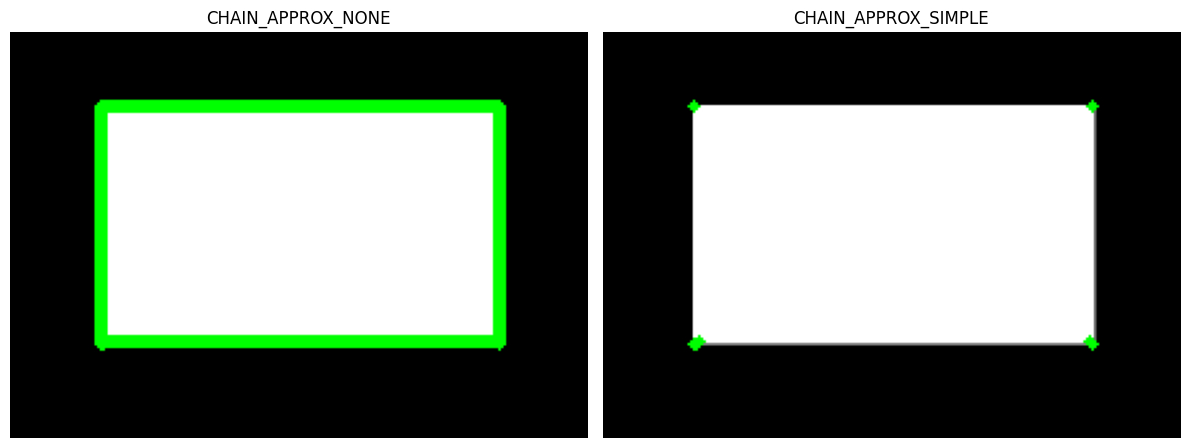

In [12]:
rectangle_image = cv2.imread(rectangle_path, cv2.IMREAD_GRAYSCALE)
if rectangle_image is None:
  raise FileNotFoundError('Rectangle Image Not Found')

_, rectangle_threshold_image = cv2.threshold(rectangle_image, 127, 255, cv2.THRESH_BINARY)

contours_none, hierarchy_none = cv2.findContours(rectangle_threshold_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

if len(contours_none) == 0:
  raise ValueError('No Contours Found In Rectangle Image')

print('CHAIN_APPROX_NONE:')
print(
    f'contours_none[0].shape: {contours_none[0].shape}; '
    f'Number Of Points: {len(contours_none[0])}'
)

none_image = cv2.cvtColor(rectangle_image, cv2.COLOR_GRAY2BGR)

for point in contours_none[0]:
  x, y = point[0]
  cv2.circle(none_image, (x, y), 2, (0, 255, 0), -1)

contours_sample, hierarchy_sample = cv2.findContours(rectangle_threshold_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

print('CHAIN_APPROX_SIMPLE:')
print(
    f'contours_sample[0].shape: {contours_sample[0].shape}; '
    f'Number Of Points: {len(contours_sample[0])}'
)

sample_image = cv2.cvtColor(rectangle_image, cv2.COLOR_GRAY2BGR)

for point in contours_sample[0]:
  x, y = point[0]
  cv2.circle(sample_image, (x, y), 2, (0, 255, 0), -1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(none_image, cmap='gray')
plt.title('CHAIN_APPROX_NONE')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_image, cmap='gray')
plt.title('CHAIN_APPROX_SIMPLE')
plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
output_images = {
    'first_contour.png': cv2.cvtColor(first_contour_image, cv2.COLOR_RGB2BGR),
    'last_contour.png': cv2.cvtColor(last_contour_image, cv2.COLOR_RGB2BGR),
    'all_contours.png': cv2.cvtColor(all_contours_image, cv2.COLOR_RGB2BGR),
    'selected_contour.png': cv2.cvtColor(selected_contour_image, cv2.COLOR_RGB2BGR),
    'chain_approx_none.png': cv2.cvtColor(none_image, cv2.COLOR_RGB2BGR),
    'chain_approx_simple.png': cv2.cvtColor(sample_image, cv2.COLOR_RGB2BGR),
}

for filename, image in output_images.items():
  output_path = '/content/' + filename
  cv2.imwrite(output_path, image)
  files.download(output_path)
  print(f'Saved {filename}')
  print(f'Downloaded {filename}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved first_contour.png
Downloaded first_contour.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Saved chain_approx_none.png
Downloaded chain_approx_none.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved chain_approx_simple.png
Downloaded chain_approx_simple.png
